### IMPORTING LIBRARIES

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.axes as ax

### READING CSV AND ANALYSING ITS STRUCTURE

In [46]:
data = pd.read_csv("data_for_lr.csv")
data.head(10)

,x,y
0,24.0,21.549452
1,50.0,47.464463
2,15.0,17.218656
3,38.0,36.586398
4,87.0,87.288984
5,36.0,32.463875
6,12.0,10.780897
7,81.0,80.763399
8,25.0,24.612151
9,5.0,6.963319


In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       700 non-null    float64
 1   y       699 non-null    float64
dtypes: float64(2)
memory usage: 11.1 KB


In [48]:
data.isnull().sum()

x    0
y    1
dtype: int64

### DATA PROCESSING

In [49]:
data.dropna(inplace=True)
data.shape

(699, 2)

### SPLITTING DATA

Training Input and Output

In [50]:
train_input = np.array(data.x.iloc[0:500]).reshape(500,1)
train_output = np.array(data.y.iloc[0:500]).reshape(500,1)

Testing Input and Output

In [64]:
test_input = np.array(data.x.iloc[500:699]).reshape(199,1)
test_output = np.array(data.y.iloc[500:699]).reshape(199,1)

# LINEAR REGRESSION

### Forward Propogation

In [52]:
def forward_propagation(train_input, parameters):
    m = parameters["m"]
    c = parameters["c"]
    predictions = np.multiply(m,train_input)+ c
    return predictions

### Cost Function

In [53]:
def cost_function(predictions,train_output):
    cost = np.mean((predictions - train_output)**2)*0.5
    return cost

### Gradient Descent for Backward Propagation

In [54]:
def backward_propagation(predictions, train_input, train_output):
    derivatives = dict()
    df = predictions - train_output
    dm = np.mean(df*train_input)
    dc = np.mean(df)
    derivatives["dm"] = dm
    derivatives["dc"] = dc
    return derivatives

### Updating Parameters

In [55]:
def update_parameters(parameters, derivatives, learning_rate):
    parameters["m"] = parameters["m"] - (learning_rate * derivatives["dm"])
    parameters["c"] = parameters["c"] - (learning_rate * derivatives["dc"])
    return parameters

# MODEL TRAINING

In [56]:
def train(train_input, train_output, learning_rate, iters):
    parameters = dict()
    parameters["m"] = np.random.uniform(0,1)
    parameters["c"] = np.random.uniform(0,1)

    plt.figure()
    loss = list()

    for i in range(iters):
        predictions = forward_propagation(train_input, parameters)

        cost = cost_function(predictions, train_output)
        loss.append(cost)
        print(f"Iteration = {i+1}, Loss = {cost}")

        fig, ax = plt.subplots()
        ax.plot(train_input, train_output, "+", label = "Original")
        ax.plot(train_input, predictions, "*", label = "Training")
        legend = ax.legend()
        plt.plot(train_input, train_output, "+", label = "Original")
        plt.plot(train_input, predictions, "*", label = "Training")
        plt.show()

        derivatives = backward_propagation(predictions, train_input, train_output)
        parameters = update_parameters(parameters, derivatives, learning_rate)
    
    return parameters,loss

Iteration = 1, Loss = 716.2624197614414


<Figure size 640x480 with 0 Axes>

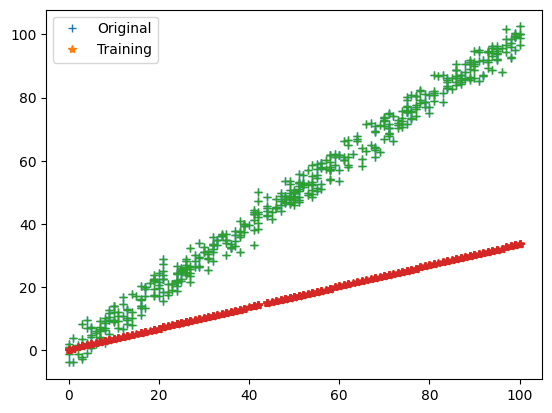

Iteration = 2, Loss = 327.12137986901723


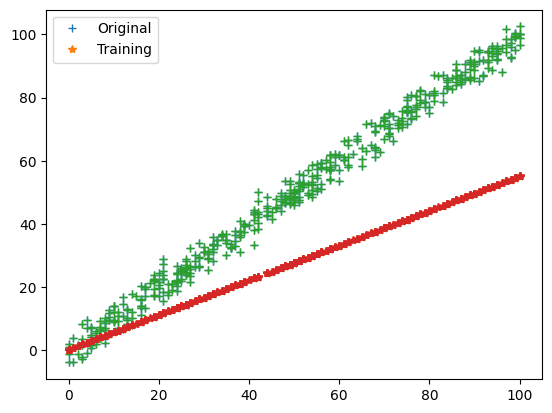

Iteration = 3, Loss = 150.56765823010176


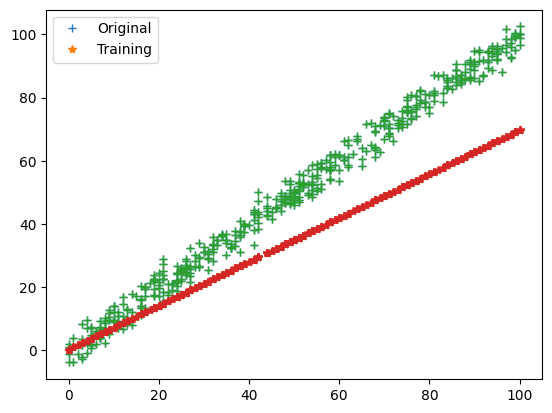

Iteration = 4, Loss = 70.46503835331943


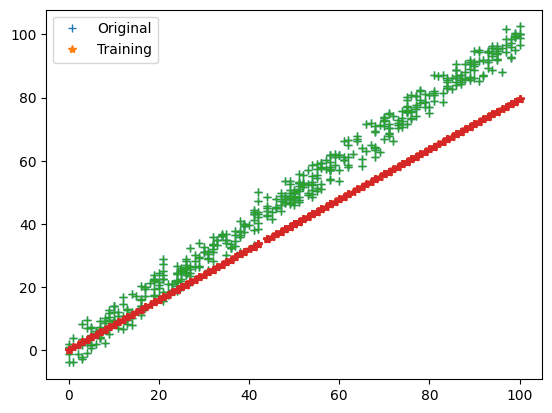

Iteration = 5, Loss = 34.12239017927318


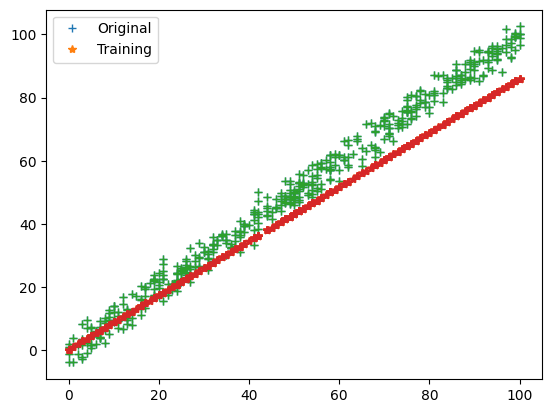

Iteration = 6, Loss = 17.633689637147295


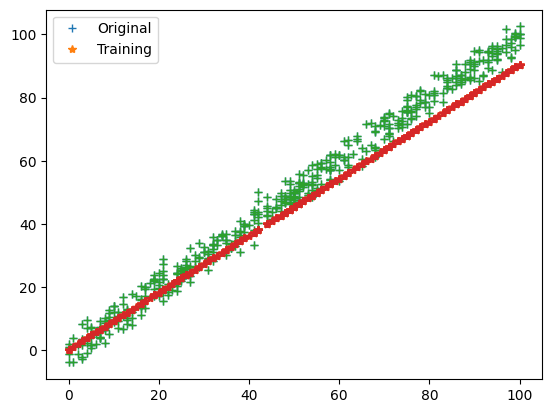

Iteration = 7, Loss = 10.152747126715228


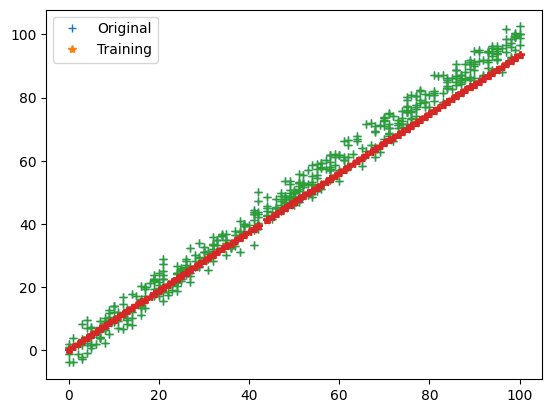

Iteration = 8, Loss = 6.758634412667494


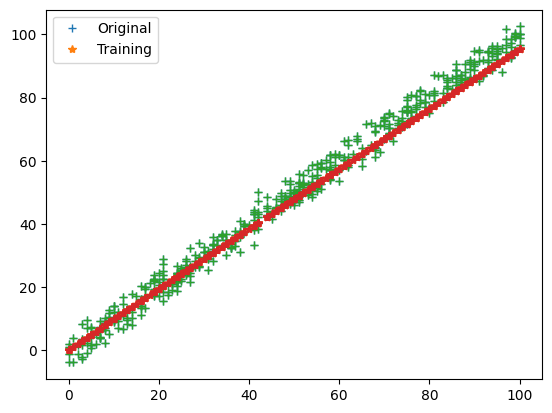

Iteration = 9, Loss = 5.21872090402132


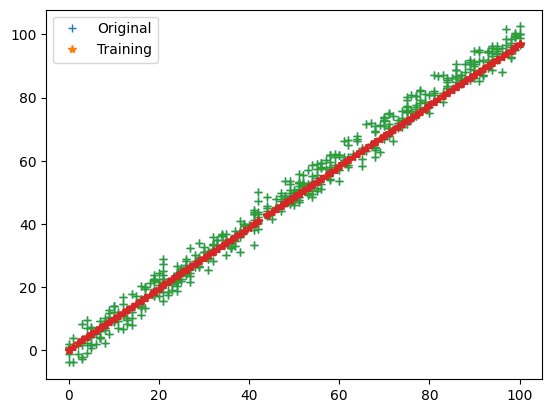

Iteration = 10, Loss = 4.520059628694125


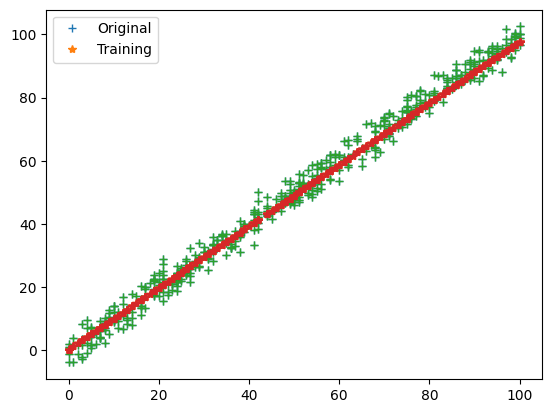

Iteration = 11, Loss = 4.2030754234702545


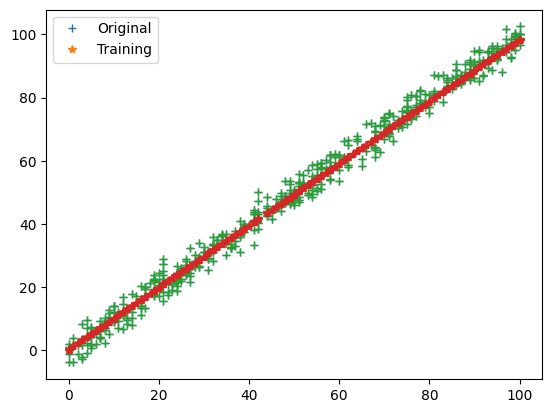

Iteration = 12, Loss = 4.059258527754342


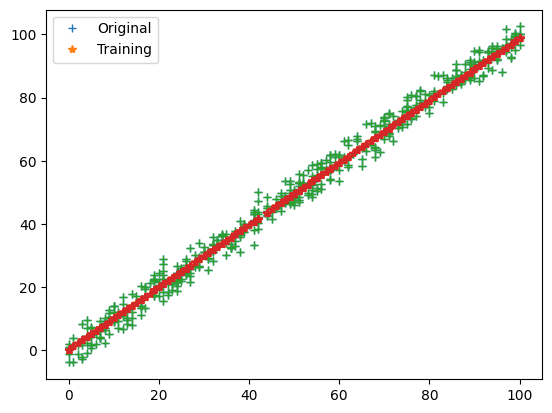

Iteration = 13, Loss = 3.994007832210281


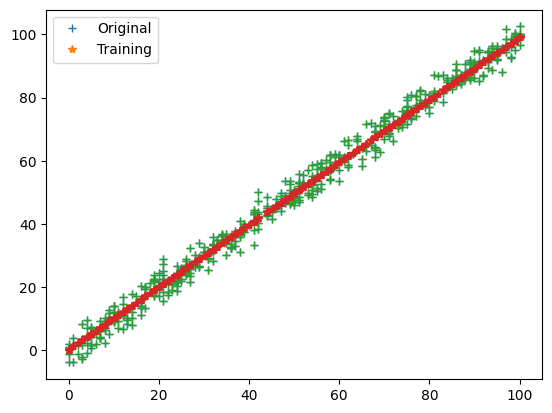

Iteration = 14, Loss = 3.964402708748187


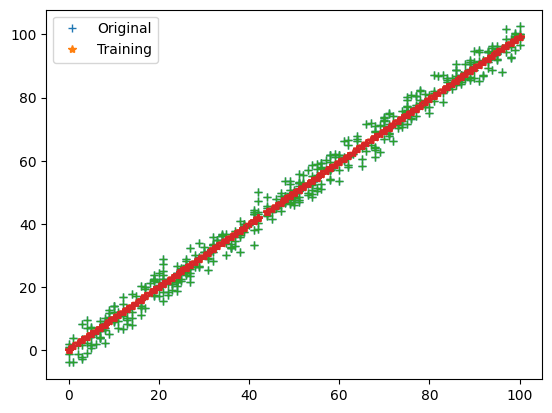

Iteration = 15, Loss = 3.9509700208630165


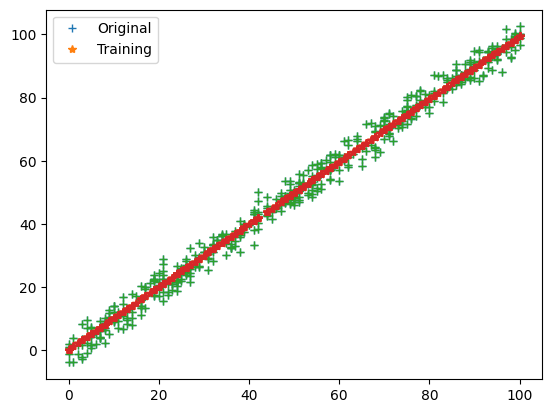

Iteration = 16, Loss = 3.9448747849531873


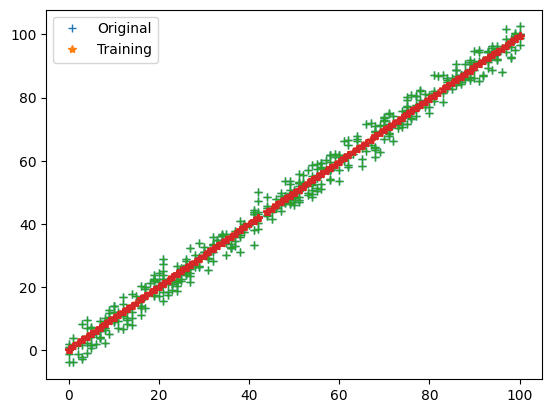

Iteration = 17, Loss = 3.9421085591726635


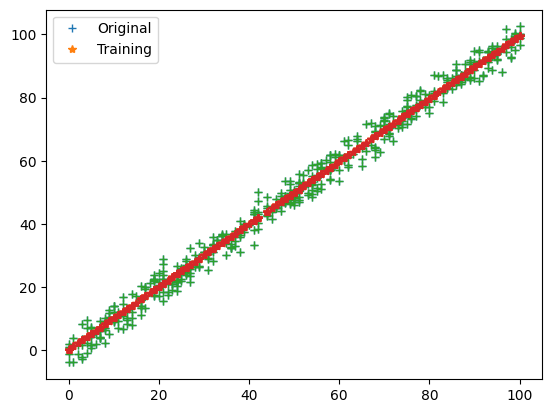

Iteration = 18, Loss = 3.9408527090159815


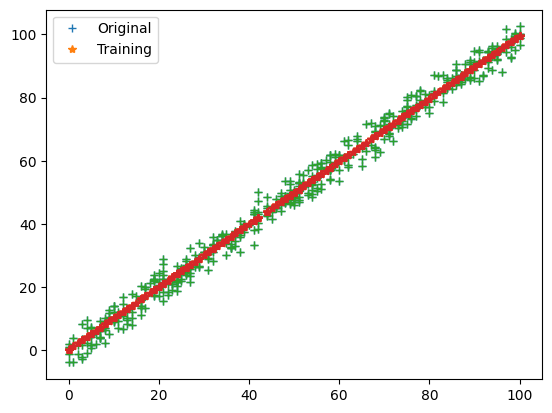

Iteration = 19, Loss = 3.940282117993616


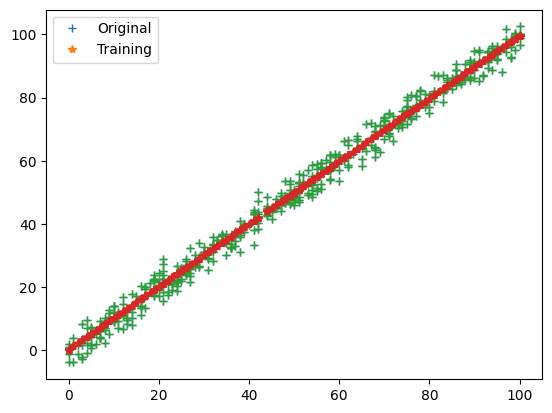

Iteration = 20, Loss = 3.9400224298403357


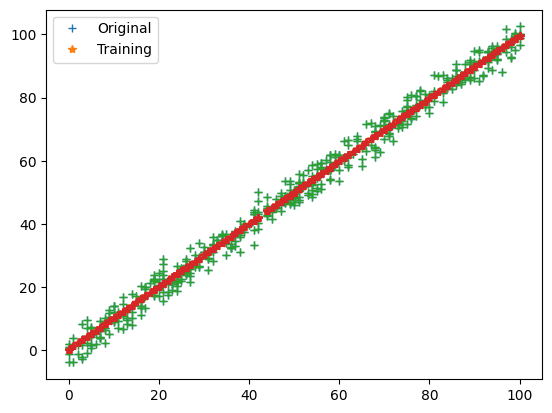

In [57]:
parameters, loss = train(train_input, train_output, 0.0001, 20)

In [58]:
parameters

{'m': 0.9934344469188271, 'c': 0.247456540433987}

In [59]:
loss

[716.2624197614414,
 327.12137986901723,
 150.56765823010176,
 70.46503835331943,
 34.12239017927318,
 17.633689637147295,
 10.152747126715228,
 6.758634412667494,
 5.21872090402132,
 4.520059628694125,
 4.2030754234702545,
 4.059258527754342,
 3.994007832210281,
 3.964402708748187,
 3.9509700208630165,
 3.9448747849531873,
 3.9421085591726635,
 3.9408527090159815,
 3.940282117993616,
 3.9400224298403357]

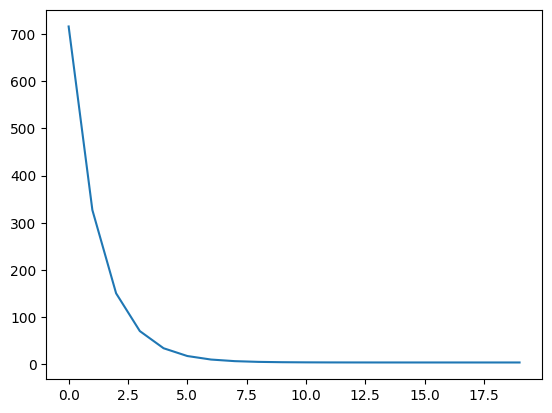

In [60]:
plt.plot(loss)

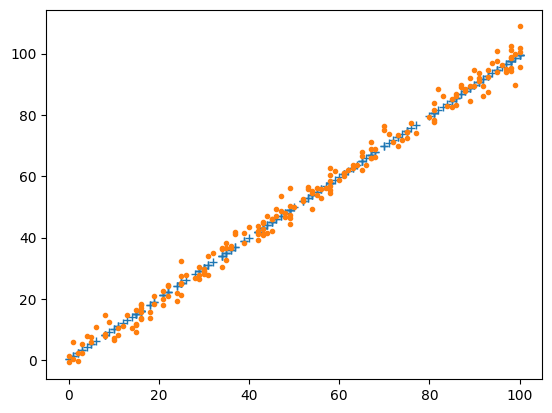

In [71]:
test_prediction = test_input * parameters["m"] + parameters["c"]
plt.plot(test_input,test_prediction, "+")
plt.plot(test_input, test_output, ".")
plt.show()

In [72]:
cost_function(test_prediction,test_output)

3.9954913009679354